# EDA — Dataset LSM
Exploración del parquet de landmarks de lengua de señas mexicana.

In [1]:
import io
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

PARQUET = '../corpus_LSM_esp/lsm_dataset.parquet'  # <-- cambia si tu archivo tiene otro nombre

# ── helpers ──────────────────────────────────────────────────────────────────
def load_kpts(b: bytes) -> np.ndarray:
    """bytes → tensor (T, 133, 3)  [x, y, score]"""
    return np.load(io.BytesIO(b))

def load_det(b: bytes) -> np.ndarray:
    """bytes → array bool (T,)"""
    return np.load(io.BytesIO(b))

# Regiones COCO-WholeBody
REGIONS = {
    'body':   slice(0,   17),
    'foot_l': slice(17,  21),
    'foot_r': slice(21,  25),
    'face':   slice(25,  92),
    'hand_l': slice(92,  113),
    'hand_r': slice(113, 134),
}
SCORE_THRESH = 0.3   # umbral para considerar un landmark 'detectado'

## 1. Carga y vista general

In [2]:
# Cargamos solo columnas de metadata primero (sin los blobs binarios)
# para que sea rápido incluso con miles de videos
META_COLS = ['glosa', 'intento', 'video_id', 'fps', 'total_frames', 'width', 'height']
df_meta = pq.read_table(PARQUET, columns=META_COLS).to_pandas()

print(f'Videos totales : {len(df_meta):,}')
print(f'Glosas únicas  : {df_meta["glosa"].nunique():,}')
print(f'Intentos únicos: {df_meta["intento"].nunique():,}')
df_meta.head(10)

Videos totales : 2,447
Glosas únicas  : 249
Intentos únicos: 2,446


,glosa,intento,video_id,fps,total_frames,width,height
0,001,01001,001_01001,30.000000,70,640,480
1,001,02001,001_02001,30.000031,136,1920,1080
2,001,03001,001_03001,30.000000,78,640,480
3,001,04001,001_04001,30.000000,116,640,480
4,001,05001,001_05001,30.000031,107,640,480
5,001,06001,001_06001,30.000031,61,640,480
6,001,07001,001_07001,30.000031,78,640,480
7,001,08001,001_08001,30.000031,79,640,480
8,001,09001,001_09001,30.000031,58,640,480
9,001,10001,001_10001,30.000031,58,640,480


In [3]:
df_meta.describe()

,fps,total_frames,width,height
count,2447.000000,2447.000000,2447.000000,2447.000000
mean,29.997137,61.259910,745.729465,530.069473
std,0.039281,21.597681,349.161402,163.791803
min,29.531193,9.000000,640.000000,480.000000
25%,30.000000,48.000000,640.000000,480.000000
50%,30.000000,57.000000,640.000000,480.000000
75%,30.000000,70.000000,640.000000,480.000000
max,30.306789,196.000000,1920.000000,1080.000000


## 2. Distribución de duración y FPS

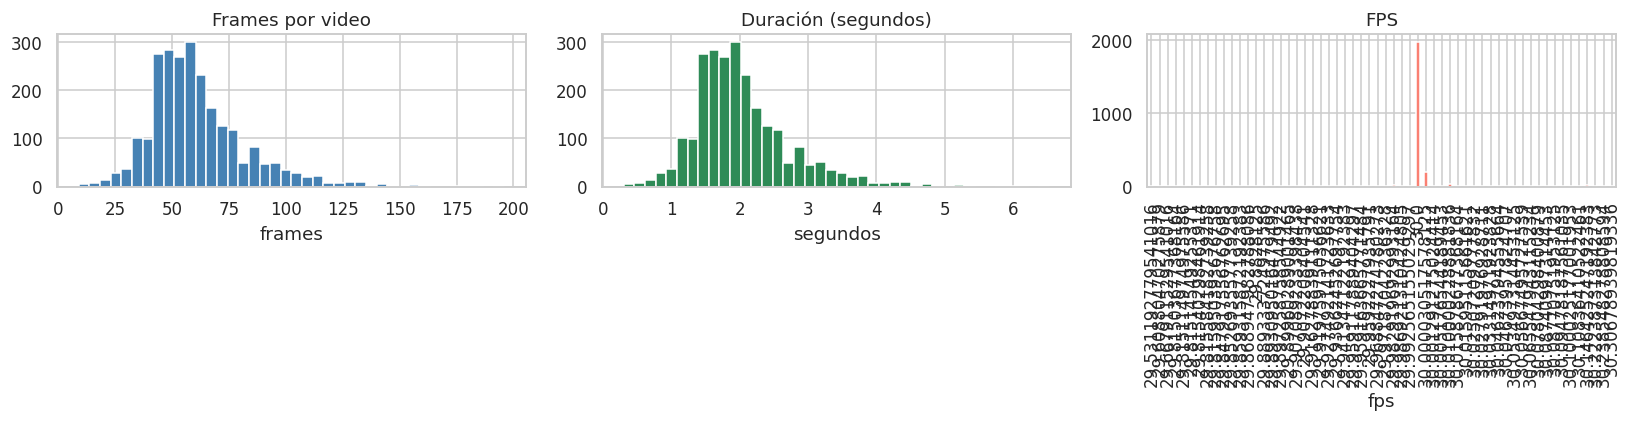

       total_frames  duration_s      fps
count       2447.00     2447.00  2447.00
mean          61.26        2.04    30.00
std           21.60        0.72     0.04
min            9.00        0.30    29.53
25%           48.00        1.60    30.00
50%           57.00        1.90    30.00
75%           70.00        2.33    30.00
max          196.00        6.53    30.31


In [4]:
df_meta['duration_s'] = df_meta['total_frames'] / df_meta['fps']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_meta['total_frames'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Frames por video')
axes[0].set_xlabel('frames')

df_meta['duration_s'].hist(bins=40, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Duración (segundos)')
axes[1].set_xlabel('segundos')

df_meta['fps'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('FPS')
axes[2].set_xlabel('fps')

plt.tight_layout()
plt.show()

print(df_meta[['total_frames','duration_s','fps']].describe().round(2))

## 3. Intentos por glosa — ¿hay glosas con menos muestras?

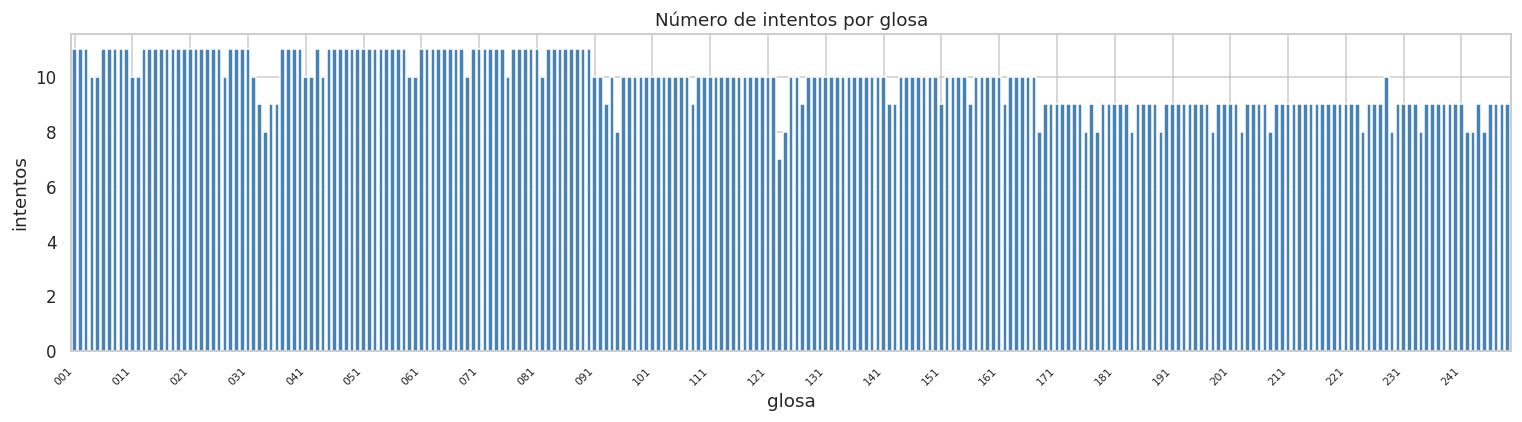

Glosas con menos de 5 intentos:
Series([], )


In [5]:
intentos_x_glosa = df_meta.groupby('glosa').size()

fig, ax = plt.subplots(figsize=(14, 4))
intentos_x_glosa.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Número de intentos por glosa')
ax.set_xlabel('glosa')
ax.set_ylabel('intentos')
ax.xaxis.set_major_locator(mticker.MaxNLocator(30))
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

print('Glosas con menos de 5 intentos:')
print(intentos_x_glosa[intentos_x_glosa < 5].to_string())

## 4. Análisis de detección — ¿frames sin persona?

In [6]:
# Cargamos solo person_detected para calcular estadísticas de detección
df_full = pq.read_table(PARQUET, columns=['video_id','glosa','total_frames','person_detected']).to_pandas()

def detection_stats(row):
    det = load_det(row['person_detected'])        # (T,) bool
    T   = len(det)
    detected_frames  = det.sum()
    missing_frames   = T - detected_frames
    pct_missing      = missing_frames / T * 100 if T > 0 else 0
    # 'perdida de detección': secuencias consecutivas sin persona
    gaps = np.diff(np.concatenate([[0], det.astype(int), [1]])) < 0
    n_gaps = gaps.sum()
    return pd.Series({
        'detected_frames': int(detected_frames),
        'missing_frames':  int(missing_frames),
        'pct_missing':     round(float(pct_missing), 2),
        'n_detection_gaps': int(n_gaps),
    })

print('Calculando estadísticas de detección...')
det_stats = df_full.apply(detection_stats, axis=1)
df_det = pd.concat([df_full[['video_id','glosa','total_frames']], det_stats], axis=1)
df_det.head()

Calculando estadísticas de detección...


,video_id,glosa,total_frames,detected_frames,missing_frames,pct_missing,n_detection_gaps
0,001_01001,001,70,70.0,0.0,0.0,0.0
1,001_02001,001,136,136.0,0.0,0.0,0.0
2,001_03001,001,78,78.0,0.0,0.0,0.0
3,001_04001,001,116,116.0,0.0,0.0,0.0
4,001_05001,001,107,107.0,0.0,0.0,0.0


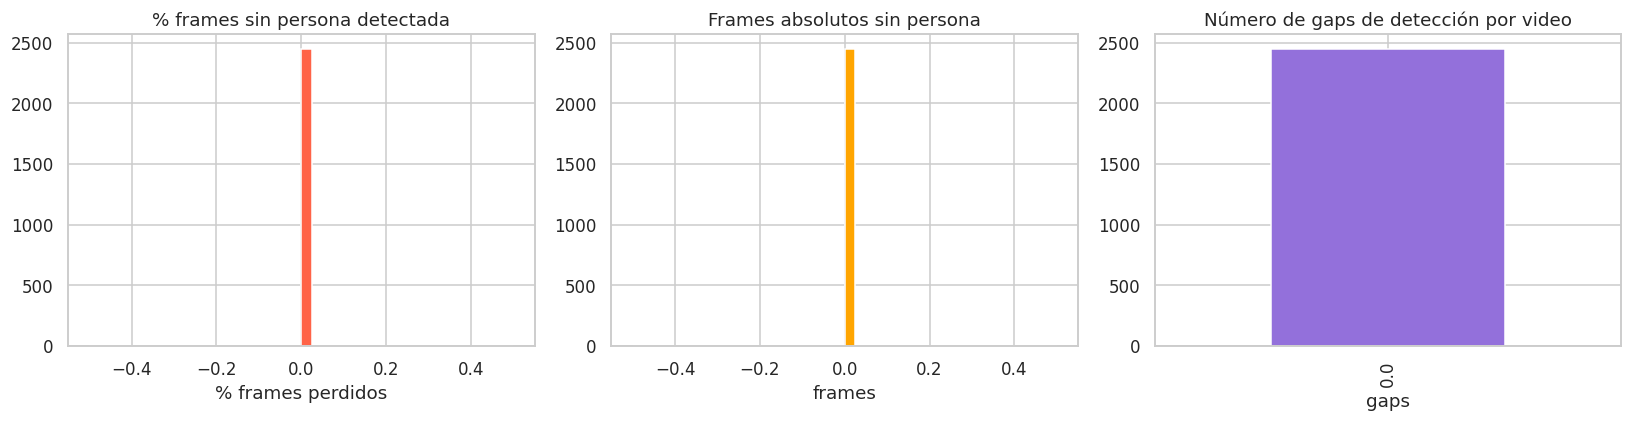

Videos con detección perfecta  (0% perdido)  : 2,447  (100.0%)
Videos con pérdida leve    (0-20% perdido)   : 0  (0.0%)
Videos con pérdida severa  (>20% perdido)    : 0  (0.0%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_det['pct_missing'].hist(bins=40, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('% frames sin persona detectada')
axes[0].set_xlabel('% frames perdidos')

df_det['missing_frames'].hist(bins=40, ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Frames absolutos sin persona')
axes[1].set_xlabel('frames')

df_det['n_detection_gaps'].value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Número de gaps de detección por video')
axes[2].set_xlabel('gaps')

plt.tight_layout()
plt.show()

n_perfect   = (df_det['missing_frames'] == 0).sum()
n_partial   = ((df_det['pct_missing'] > 0) & (df_det['pct_missing'] <= 20)).sum()
n_bad       = (df_det['pct_missing'] > 20).sum()

print(f'Videos con detección perfecta  (0% perdido)  : {n_perfect:,}  ({n_perfect/len(df_det)*100:.1f}%)')
print(f'Videos con pérdida leve    (0-20% perdido)   : {n_partial:,}  ({n_partial/len(df_det)*100:.1f}%)')
print(f'Videos con pérdida severa  (>20% perdido)    : {n_bad:,}  ({n_bad/len(df_det)*100:.1f}%)')

In [8]:
# Los 20 videos más problemáticos
df_det.sort_values('pct_missing', ascending=False).head(20)[
    ['video_id','glosa','total_frames','missing_frames','pct_missing','n_detection_gaps']
]

,video_id,glosa,total_frames,missing_frames,pct_missing,n_detection_gaps
0,001_01001,001,70,0.0,0.0,0.0
1,001_02001,001,136,0.0,0.0,0.0
2,001_03001,001,78,0.0,0.0,0.0
3,001_04001,001,116,0.0,0.0,0.0
4,001_05001,001,107,0.0,0.0,0.0
5,001_06001,001,61,0.0,0.0,0.0
6,001_07001,001,78,0.0,0.0,0.0
7,001_08001,001,79,0.0,0.0,0.0
8,001_09001,001,58,0.0,0.0,0.0
9,001_10001,001,58,0.0,0.0,0.0


## 5. Calidad de landmarks por región

/tmp/ipykernel_828961/1579418361.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


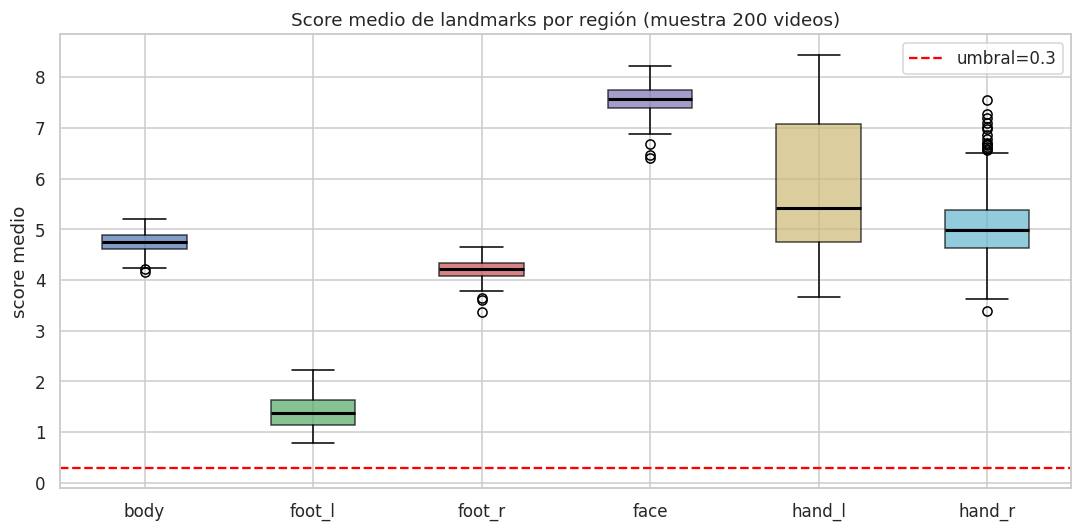

In [9]:
# Muestreamos N videos para no tardar siglos
SAMPLE_N = min(200, len(df_full))
sample_idx = np.random.choice(len(df_full), SAMPLE_N, replace=False)

df_kpts = pq.read_table(PARQUET, columns=['video_id','person_detected','keypoints']).to_pandas()

region_scores = {r: [] for r in REGIONS}

for i in sample_idx:
    row  = df_kpts.iloc[i]
    det  = load_det(row['person_detected'])    # (T,)
    kpts = load_kpts(row['keypoints'])         # (T, 133, 3)
    # solo frames donde se detectó persona
    kpts_det = kpts[det]
    if len(kpts_det) == 0:
        continue
    for region, sl in REGIONS.items():
        scores = kpts_det[:, sl, 2]            # (T_det, n_kpts_region)
        mean_score = scores.mean()
        region_scores[region].append(mean_score)

# Boxplot por región
fig, ax = plt.subplots(figsize=(10, 5))
data   = [region_scores[r] for r in REGIONS]
labels = list(REGIONS.keys())
bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(SCORE_THRESH, ls='--', color='red', lw=1.5, label=f'umbral={SCORE_THRESH}')
ax.set_title(f'Score medio de landmarks por región (muestra {SAMPLE_N} videos)')
ax.set_ylabel('score medio')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# % de landmarks bajo el umbral por región
print(f'% frames con score < {SCORE_THRESH} (landmark considerado perdido):')
for region, scores in region_scores.items():
    arr  = np.array(scores)
    bajo = (arr < SCORE_THRESH).mean() * 100
    print(f'  {region:<8}: {bajo:.1f}%  (media score: {arr.mean():.3f})')

% frames con score < 0.3 (landmark considerado perdido):
  body    : 0.0%  (media score: 4.737)
  foot_l  : 0.0%  (media score: 1.417)
  foot_r  : 0.0%  (media score: 4.202)
  face    : 0.0%  (media score: 7.555)
  hand_l  : 0.0%  (media score: 5.853)
  hand_r  : 0.0%  (media score: 5.130)


## 6. Heatmap espacial — ¿dónde aparecen las manos?

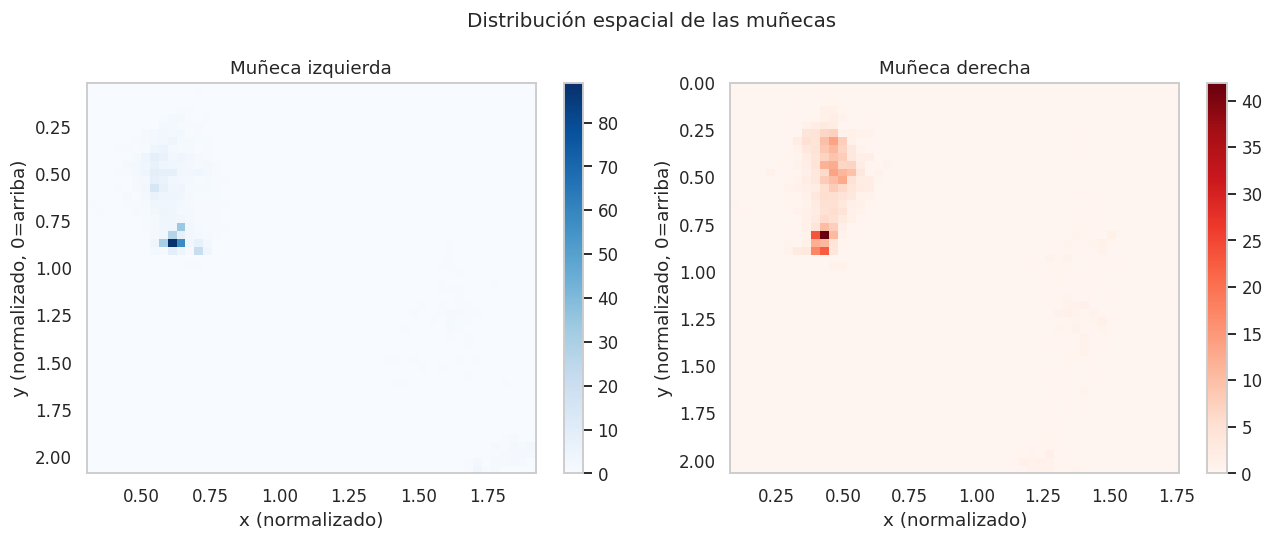

In [11]:
# Acumula posiciones de muñeca izq (kpt 92) y muñeca der (kpt 113)
xs_l, ys_l = [], []
xs_r, ys_r = [], []

for i in sample_idx:
    row  = df_kpts.iloc[i]
    det  = load_det(row['person_detected'])
    kpts = load_kpts(row['keypoints'])
    kpts_det = kpts[det]
    if len(kpts_det) == 0:
        continue
    # Solo frames con score decente en la muñeca
    mask_l = kpts_det[:, 92,  2] > SCORE_THRESH
    mask_r = kpts_det[:, 113, 2] > SCORE_THRESH
    xs_l.extend(kpts_det[mask_l, 92,  0].tolist())
    ys_l.extend(kpts_det[mask_l, 92,  1].tolist())
    xs_r.extend(kpts_det[mask_r, 113, 0].tolist())
    ys_r.extend(kpts_det[mask_r, 113, 1].tolist())

# Normaliza a [0,1] usando el tamaño modal del video
W = df_meta['width'].mode()[0]
H = df_meta['height'].mode()[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, xs, ys, label, cmap in zip(
        axes,
        [xs_l, xs_r], [ys_l, ys_r],
        ['Muñeca izquierda', 'Muñeca derecha'],
        ['Blues', 'Reds']):
    h = ax.hist2d(
        np.array(xs) / W,
        np.array(ys) / H,
        bins=50, cmap=cmap, density=True
    )
    plt.colorbar(h[3], ax=ax)
    ax.invert_yaxis()
    ax.set_title(label)
    ax.set_xlabel('x (normalizado)')
    ax.set_ylabel('y (normalizado, 0=arriba)')

plt.suptitle('Distribución espacial de las muñecas', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Trayectoria de un video específico

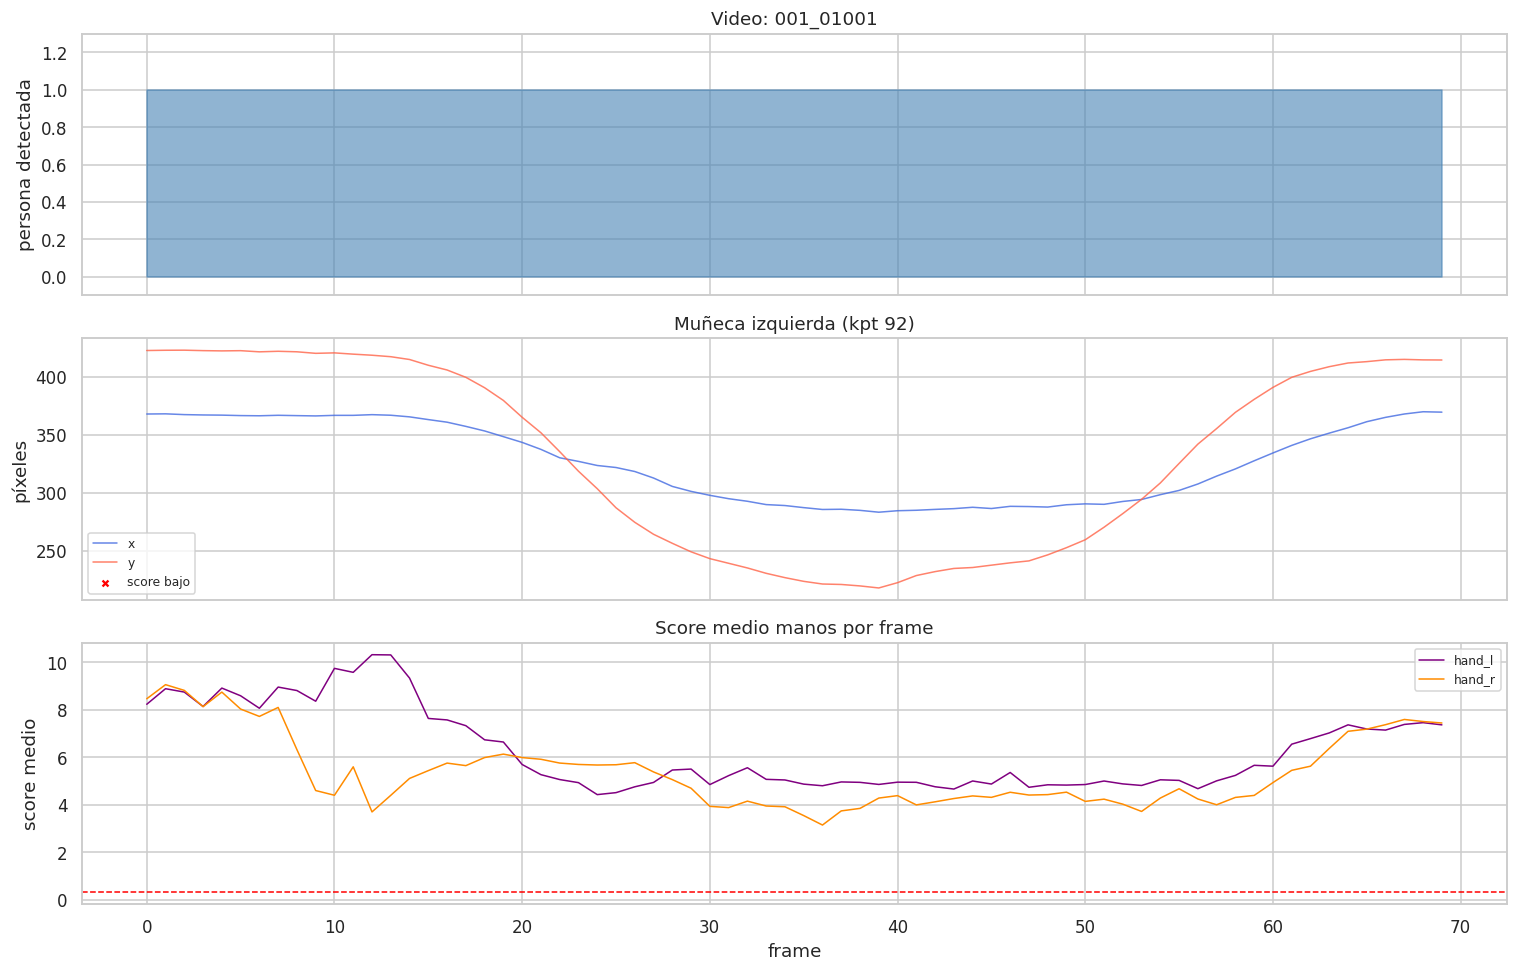

In [12]:
# Cambia video_id al que quieras inspeccionar
VIDEO_ID = df_meta['video_id'].iloc[0]

row  = df_kpts[df_kpts['video_id'] == VIDEO_ID].iloc[0]
det  = load_det(row['person_detected'])    # (T,)
kpts = load_kpts(row['keypoints'])         # (T, 133, 3)

T    = kpts.shape[0]
time = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# — Detección frame a frame
axes[0].fill_between(time, det.astype(int), alpha=0.6, color='steelblue')
axes[0].set_ylabel('persona detectada')
axes[0].set_ylim(-0.1, 1.3)
axes[0].set_title(f'Video: {VIDEO_ID}')

# — Trayectoria muñeca izquierda (x e y)
x_l = kpts[:, 92, 0];  y_l = kpts[:, 92, 1];  s_l = kpts[:, 92, 2]
mask_l = s_l > SCORE_THRESH
axes[1].plot(time, x_l, lw=1, label='x', color='royalblue', alpha=0.8)
axes[1].plot(time, y_l, lw=1, label='y', color='tomato',    alpha=0.8)
axes[1].scatter(time[~mask_l], np.full(mask_l.sum() ^ len(mask_l), np.nan),
                marker='x', color='red', s=15, label='score bajo')
axes[1].set_ylabel('píxeles')
axes[1].set_title('Muñeca izquierda (kpt 92)')
axes[1].legend(fontsize=8)

# — Score de mano izquierda promedio por frame
score_hand_l = kpts[:, 92:113, 2].mean(axis=1)
score_hand_r = kpts[:, 113:134, 2].mean(axis=1)
axes[2].plot(time, score_hand_l, lw=1, label='hand_l', color='purple')
axes[2].plot(time, score_hand_r, lw=1, label='hand_r', color='darkorange')
axes[2].axhline(SCORE_THRESH, ls='--', color='red', lw=1)
axes[2].set_ylabel('score medio')
axes[2].set_xlabel('frame')
axes[2].set_title('Score medio manos por frame')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Intentos atípicos por duración dentro de su glosa

In [13]:
# Aseguramos que duration_s existe
if 'duration_s' not in df_meta.columns:
    df_meta['duration_s'] = df_meta['total_frames'] / df_meta['fps']

# ── Estadísticas por glosa ────────────────────────────────────────────────
glosa_stats = df_meta.groupby('glosa')['duration_s'].agg(
    media='mean', mediana='median', std='std', n='count',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
).reset_index()

# IQR por glosa
glosa_stats['iqr']        = glosa_stats['q3'] - glosa_stats['q1']
glosa_stats['lim_inf']    = glosa_stats['q1'] - 1.5 * glosa_stats['iqr']
glosa_stats['lim_sup']    = glosa_stats['q3'] + 1.5 * glosa_stats['iqr']

# Unir límites a df_meta
df_out = df_meta.merge(glosa_stats[['glosa','media','mediana','std','lim_inf','lim_sup']], on='glosa')

# Marcar outliers (IQR) y outliers extremos (z-score > 3 dentro de la glosa)
df_out['outlier_iqr'] = (
    (df_out['duration_s'] < df_out['lim_inf']) |
    (df_out['duration_s'] > df_out['lim_sup'])
)

# Z-score dentro de cada glosa
df_out['zscore'] = df_out.groupby('glosa')['duration_s'].transform(
    lambda x: (x - x.mean()) / max(x.std(), 1e-6)
)
df_out['outlier_z3'] = df_out['zscore'].abs() > 3

# Desviación relativa respecto a la mediana de su glosa
df_out['dev_rel'] = ((df_out['duration_s'] - df_out['mediana']) / df_out['mediana'] * 100).round(1)

n_iqr = df_out['outlier_iqr'].sum()
n_z3  = df_out['outlier_z3'].sum()
print(f'Outliers por IQR (1.5×) : {n_iqr}  ({n_iqr/len(df_out)*100:.1f}%)')
print(f'Outliers por z-score >3 : {n_z3}  ({n_z3/len(df_out)*100:.1f}%)')

Outliers por IQR (1.5×) : 212  (8.7%)
Outliers por z-score >3 : 0  (0.0%)


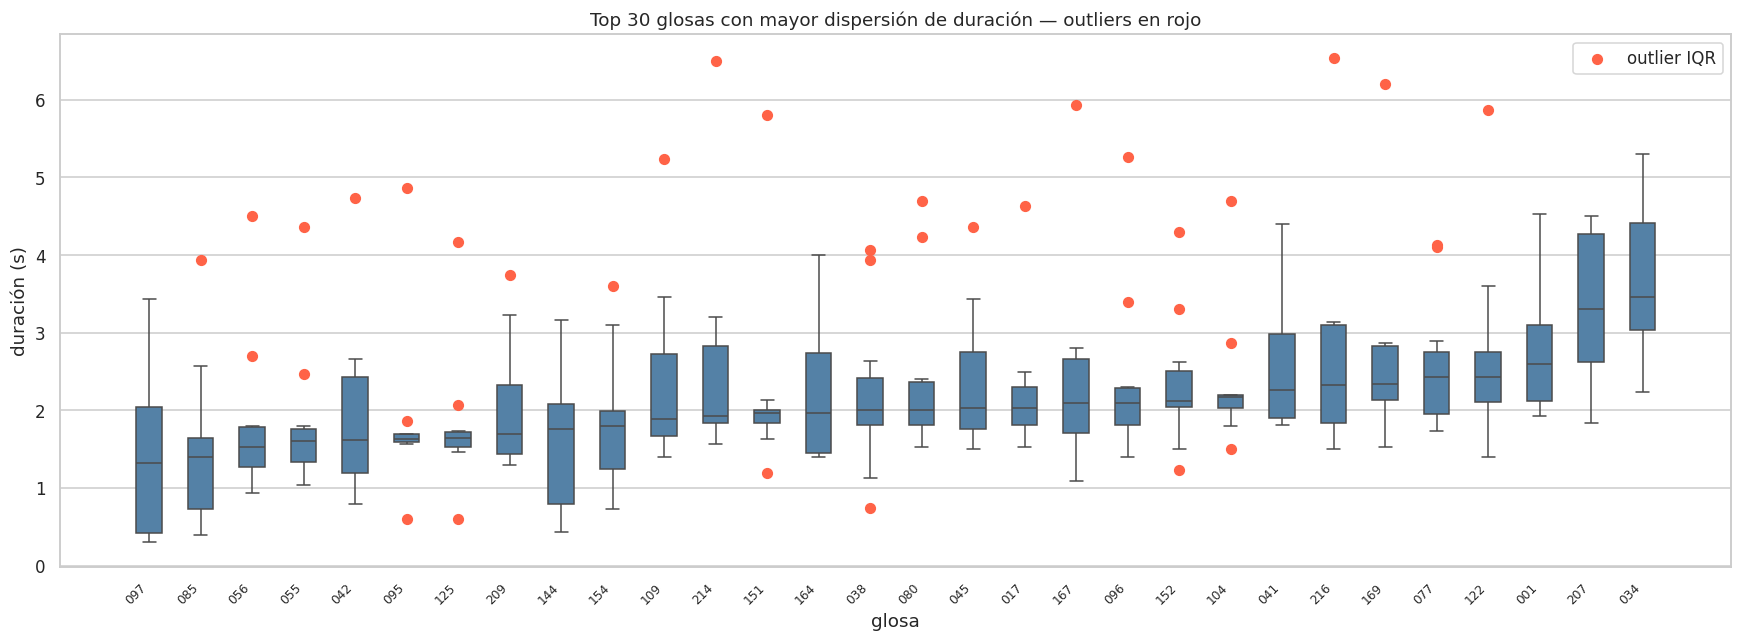

In [14]:
# ── Boxplot por glosa con outliers marcados ───────────────────────────────
# Tomamos las 30 glosas con mayor dispersión (std) para no saturar el gráfico
top_dispersas = glosa_stats.nlargest(30, 'std')['glosa'].tolist()
df_plot = df_out[df_out['glosa'].isin(top_dispersas)]

fig, ax = plt.subplots(figsize=(16, 6))
orden = df_plot.groupby('glosa')['duration_s'].median().sort_values().index

sns.boxplot(
    data=df_plot, x='glosa', y='duration_s', order=orden,
    color='steelblue', width=0.5, fliersize=0, ax=ax
)
# Outliers IQR en rojo
out_plot = df_plot[df_plot['outlier_iqr']]
ax.scatter(
    [orden.tolist().index(g) for g in out_plot['glosa']],
    out_plot['duration_s'],
    color='tomato', zorder=5, s=40, label='outlier IQR'
)
ax.set_title('Top 30 glosas con mayor dispersión de duración — outliers en rojo')
ax.set_xlabel('glosa')
ax.set_ylabel('duración (s)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

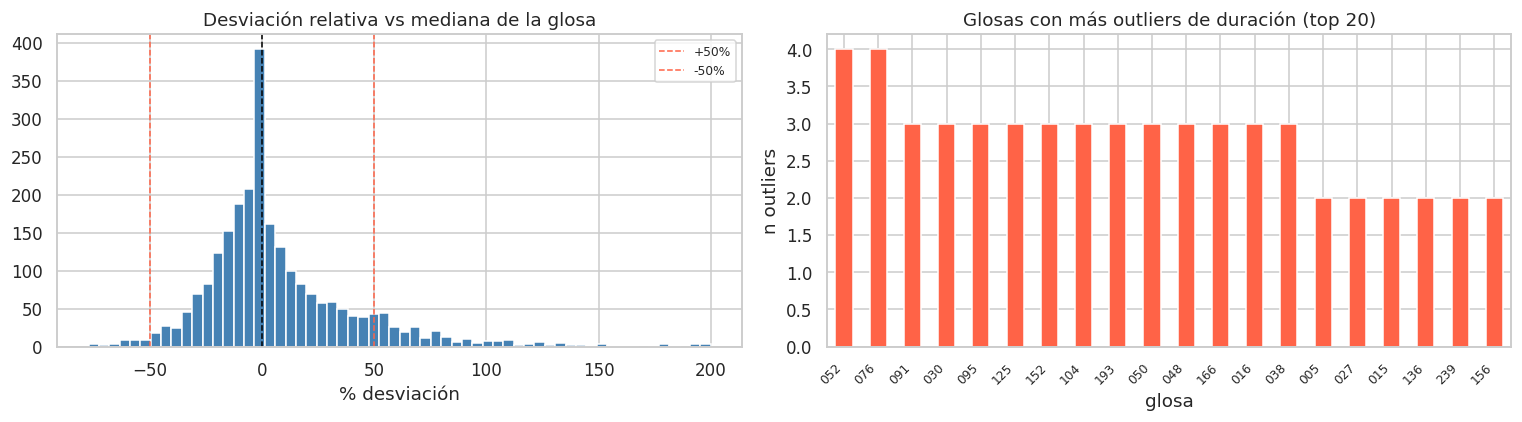

In [15]:
# ── Distribución de la desviación relativa ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_out['dev_rel'].clip(-200, 200).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(0,   ls='--', color='black', lw=1)
axes[0].axvline( 50, ls='--', color='tomato', lw=1, label='+50%')
axes[0].axvline(-50, ls='--', color='tomato', lw=1, label='-50%')
axes[0].set_title('Desviación relativa vs mediana de la glosa')
axes[0].set_xlabel('% desviación')
axes[0].legend(fontsize=8)

# Cuántos outliers tiene cada glosa
outliers_x_glosa = df_out[df_out['outlier_iqr']].groupby('glosa').size().sort_values(ascending=False)
outliers_x_glosa.head(20).plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Glosas con más outliers de duración (top 20)')
axes[1].set_xlabel('glosa')
axes[1].set_ylabel('n outliers')
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# ── Tabla de los intentos más atípicos ───────────────────────────────────
cols_show = ['video_id', 'glosa', 'intento', 'duration_s', 'mediana', 'dev_rel', 'zscore', 'outlier_z3']

df_atipicos = (
    df_out[df_out['outlier_iqr']]
    .sort_values('dev_rel', key=abs, ascending=False)
    [cols_show]
    .reset_index(drop=True)
)
df_atipicos['duration_s'] = df_atipicos['duration_s'].round(2)
df_atipicos['mediana']    = df_atipicos['mediana'].round(2)
df_atipicos['zscore']     = df_atipicos['zscore'].round(2)

print(f'Total intentos atípicos: {len(df_atipicos)}')
print(f'  — demasiado cortos (dev_rel < -50%): {(df_atipicos["dev_rel"] < -50).sum()}')
print(f'  — demasiado largos (dev_rel >  50%): {(df_atipicos["dev_rel"] >  50).sum()}')
print()
df_atipicos.head(30)

Total intentos atípicos: 212
  — demasiado cortos (dev_rel < -50%): 7
  — demasiado largos (dev_rel >  50%): 156



,video_id,glosa,intento,duration_s,mediana,dev_rel,zscore,outlier_z3
0,214_01214,214,01214,6.50,1.93,236.2,2.50,False
1,044_01044,044,01044,3.67,1.13,223.5,2.69,False
2,095_01095,095,01095,4.87,1.63,198.7,2.36,False
3,151_01151,151,01151,5.80,1.97,194.9,2.61,False
4,056_01056,056,01056,4.50,1.53,193.5,2.64,False
5,042_01042,042,01042,4.73,1.62,192.8,2.39,False
6,167_01167,167,01167,5.93,2.10,182.6,2.57,False
7,085_01085,085,01085,3.93,1.40,181.0,2.39,False
8,216_01216,216,01216,6.53,2.33,180.0,2.46,False
9,109_01109,109,01109,5.23,1.88,177.9,2.39,False


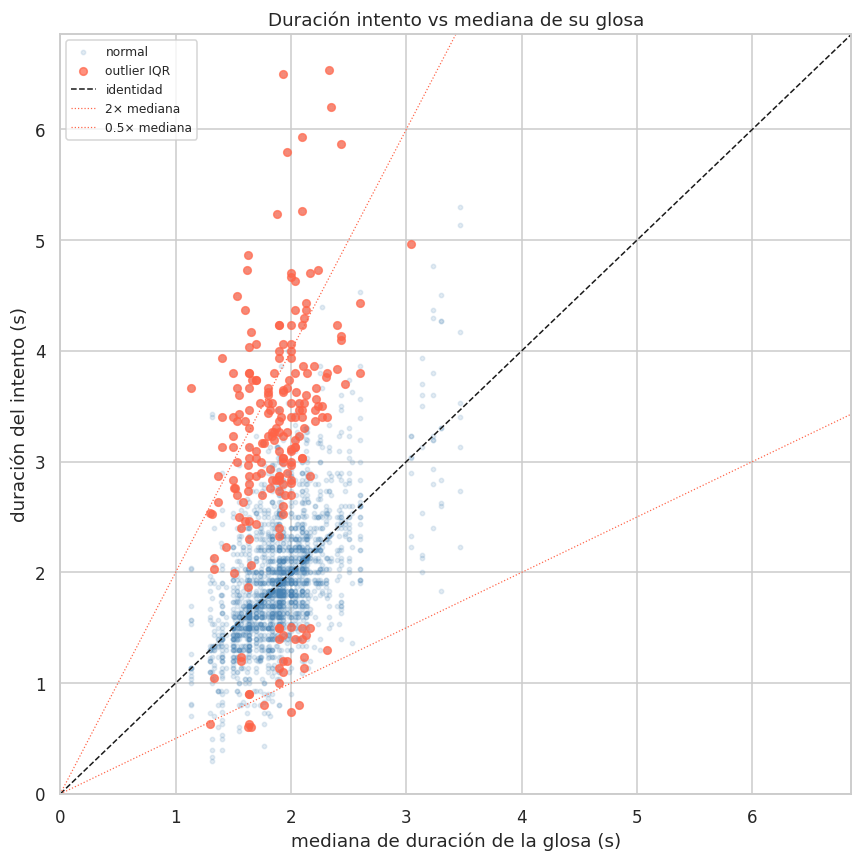

In [17]:
# ── Zoom: scatter duración real vs mediana de la glosa ───────────────────
fig, ax = plt.subplots(figsize=(8, 8))

# Fondo: todos los videos
ax.scatter(df_out['mediana'], df_out['duration_s'],
           alpha=0.15, s=8, color='steelblue', label='normal')
# Outliers IQR
ax.scatter(df_out.loc[df_out['outlier_iqr'], 'mediana'],
           df_out.loc[df_out['outlier_iqr'], 'duration_s'],
           alpha=0.7, s=25, color='tomato', label='outlier IQR')
# Línea identidad
lim = max(df_out['duration_s'].max(), df_out['mediana'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='identidad')
ax.plot([0, lim], [0, lim * 2], color='tomato', lw=0.8, ls=':', label='2× mediana')
ax.plot([0, lim], [0, lim * 0.5], color='tomato', lw=0.8, ls=':', label='0.5× mediana')

ax.set_xlabel('mediana de duración de la glosa (s)')
ax.set_ylabel('duración del intento (s)')
ax.set_title('Duración intento vs mediana de su glosa')
ax.legend(fontsize=8)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

## 9. Resumen ejecutivo

In [18]:
print('='*55)
print('RESUMEN DEL DATASET')  # sección 9
print('='*55)
print(f"Videos          : {len(df_meta):,}")
print(f"Glosas          : {df_meta['glosa'].nunique():,}")
print(f"Frames totales  : {df_meta['total_frames'].sum():,}")
print(f"Duración total  : {df_meta['duration_s'].sum()/60:.1f} min")
print(f"Duración media  : {df_meta['duration_s'].mean():.2f} s  "
      f"(σ={df_meta['duration_s'].std():.2f})")
print(f"FPS más común   : {df_meta['fps'].mode()[0]}")
print(f"Resolución modal: {df_meta['width'].mode()[0]}×{df_meta['height'].mode()[0]}")
print()
print(f"Videos 0% perdido  : {(df_det['pct_missing']==0).sum():,}")
print(f"Videos >20% perdido: {(df_det['pct_missing']>20).sum():,}")
print(f"% medio perdido    : {df_det['pct_missing'].mean():.2f}%")
print('='*55)

RESUMEN DEL DATASET
Videos          : 2,447
Glosas          : 249
Frames totales  : 149,903
Duración total  : 83.3 min
Duración media  : 2.04 s  (σ=0.72)
FPS más común   : 30.0
Resolución modal: 640×480

Videos 0% perdido  : 2,447
Videos >20% perdido: 0
% medio perdido    : 0.00%


Primeros intentos: 244
Resto: 2203


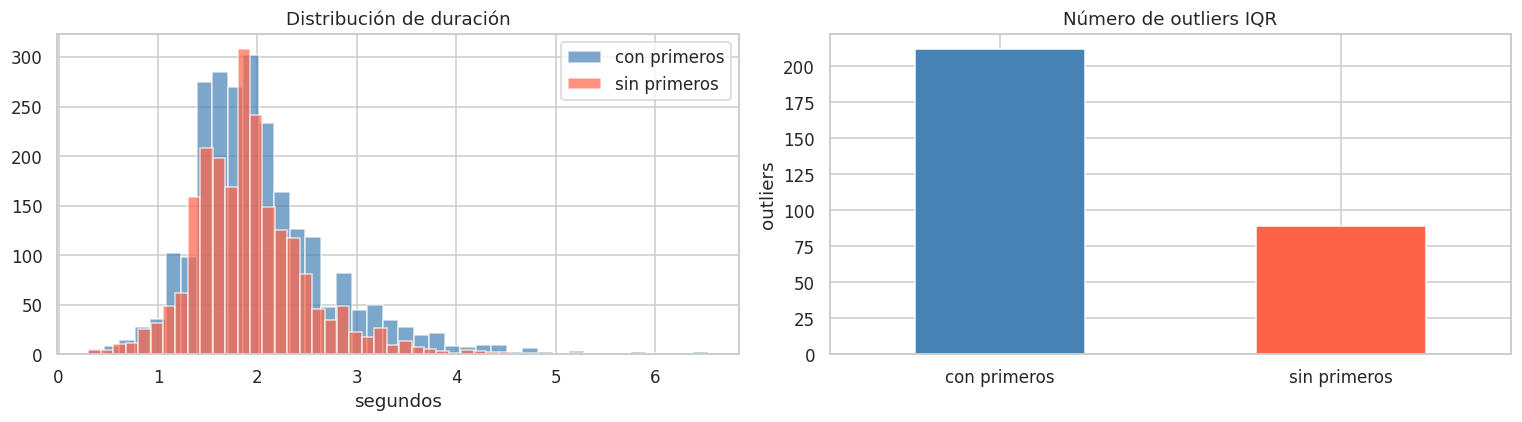


Estadísticas SIN primeros intentos:
count    2203.00
mean        1.92
std         0.58
min         0.30
25%         1.53
50%         1.83
75%         2.20
max         5.30
Name: duration_s, dtype: float64

Estadísticas CON primeros intentos:
count    2447.00
mean        2.04
std         0.72
min         0.30
25%         1.60
50%         1.90
75%         2.33
max         6.53
Name: duration_s, dtype: float64


In [19]:
# Filtrar primeros intentos
mask_primeros = df_out['intento'].str.startswith('01')
print(f"Primeros intentos: {mask_primeros.sum()}")
print(f"Resto: {(~mask_primeros).sum()}")

df_sin_primeros = df_out[~mask_primeros].copy()

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_out['duration_s'].hist(bins=40, ax=axes[0], color='steelblue', 
                           edgecolor='white', alpha=0.7, label='con primeros')
df_sin_primeros['duration_s'].hist(bins=40, ax=axes[0], color='tomato',
                                    edgecolor='white', alpha=0.7, label='sin primeros')
axes[0].set_title('Distribución de duración')
axes[0].set_xlabel('segundos')
axes[0].legend()

# Outliers antes vs después
n_out_antes  = df_out['outlier_iqr'].sum()
n_out_despues = df_sin_primeros['outlier_iqr'].sum()
pd.Series({
    'con primeros':  n_out_antes,
    'sin primeros':  n_out_despues,
}).plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Número de outliers IQR')
axes[1].set_ylabel('outliers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas SIN primeros intentos:")
print(df_sin_primeros['duration_s'].describe().round(2))
print(f"\nEstadísticas CON primeros intentos:")
print(df_out['duration_s'].describe().round(2))

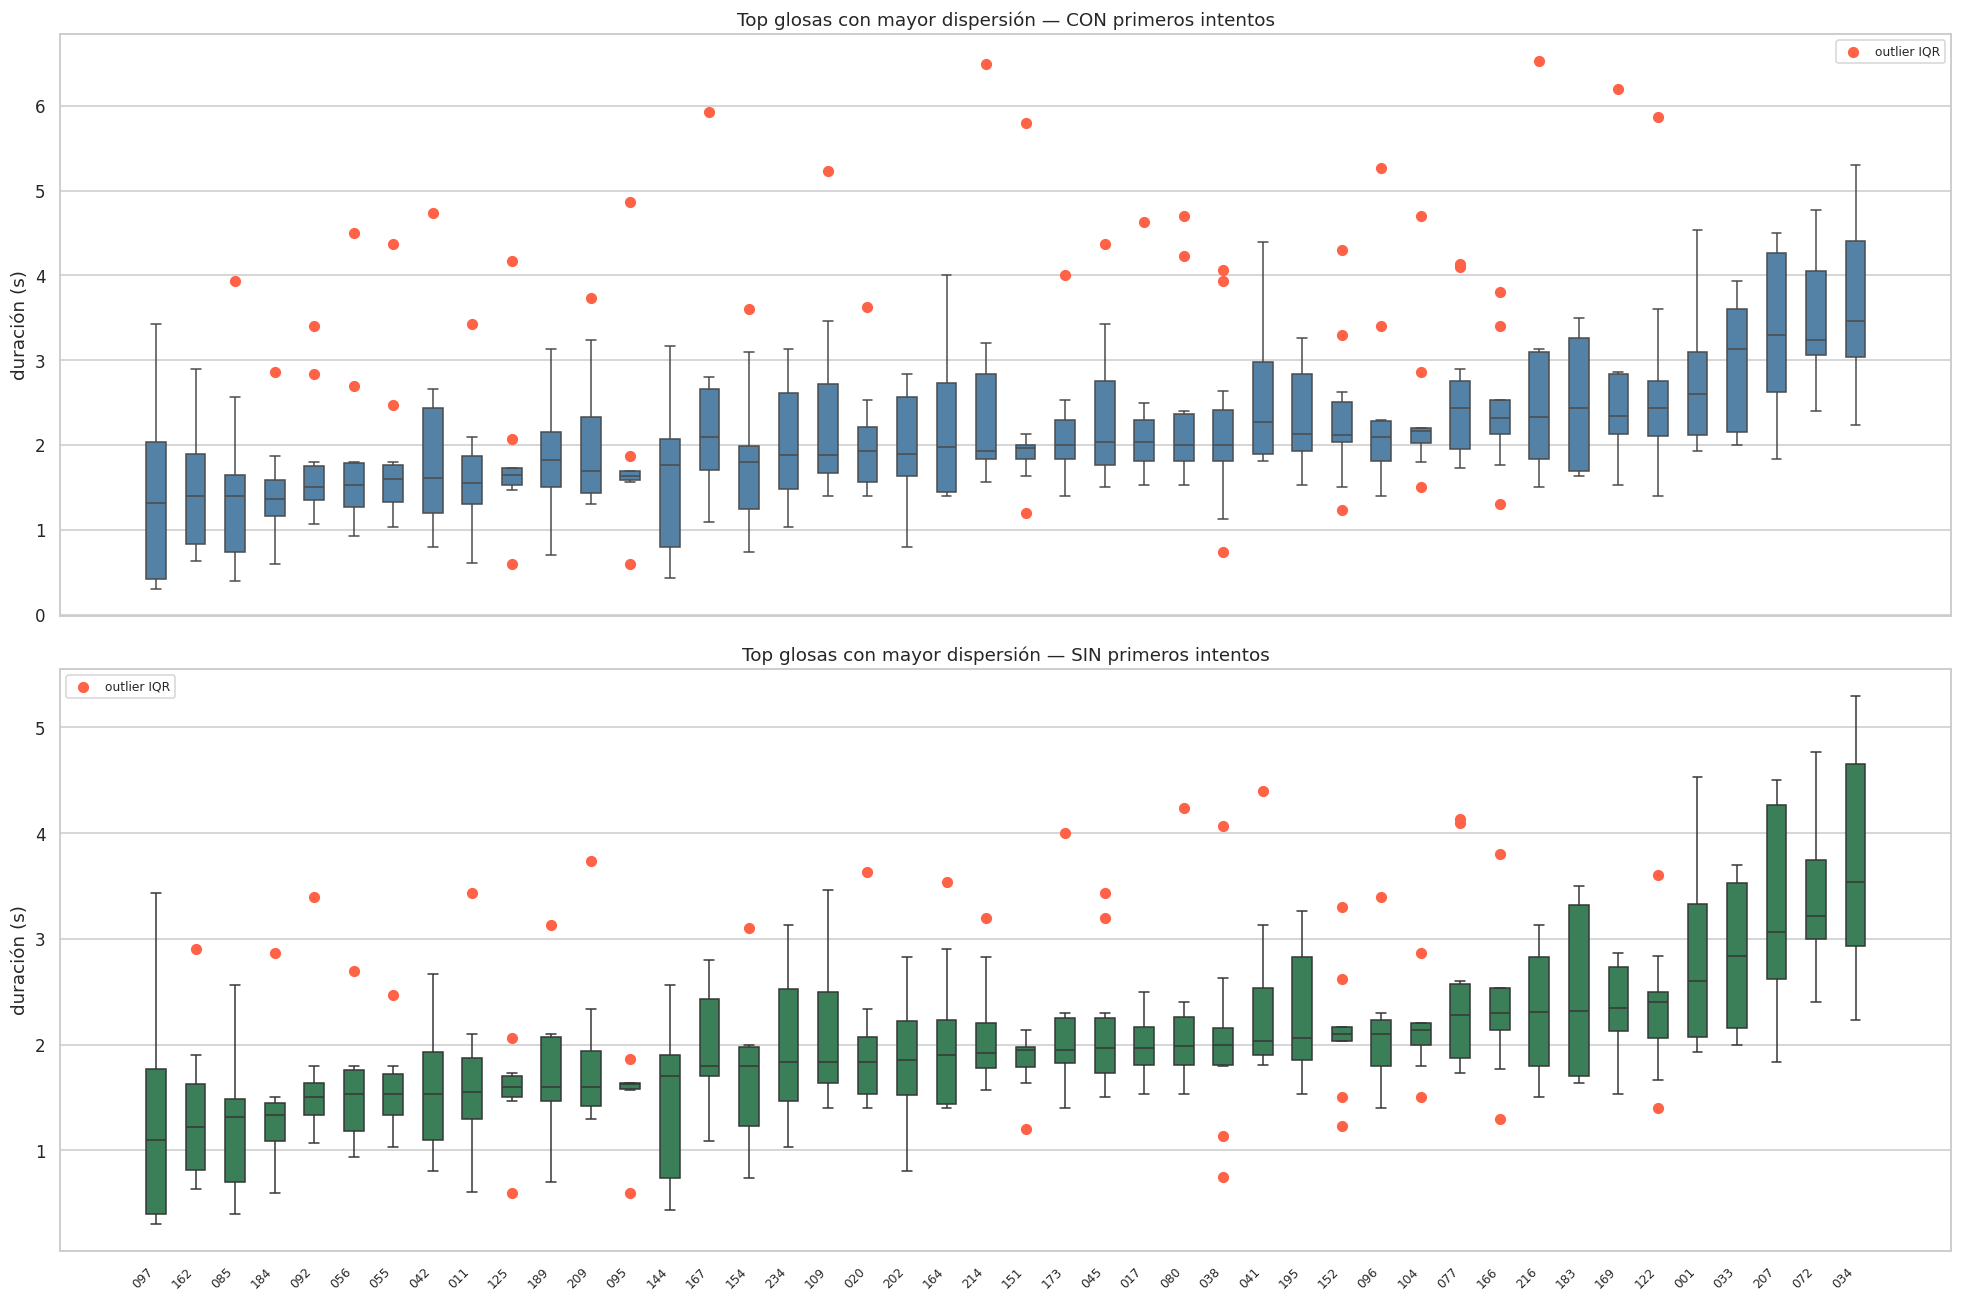

Outliers CON primeros: 212
Outliers SIN primeros: 163


In [20]:
# Recalcular glosa_stats SIN primeros intentos
glosa_stats_sin = df_sin_primeros.groupby('glosa')['duration_s'].agg(
    media='mean', mediana='median', std='std', n='count',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
).reset_index()
glosa_stats_sin['iqr']     = glosa_stats_sin['q3'] - glosa_stats_sin['q1']
glosa_stats_sin['lim_inf'] = glosa_stats_sin['q1'] - 1.5 * glosa_stats_sin['iqr']
glosa_stats_sin['lim_sup'] = glosa_stats_sin['q3'] + 1.5 * glosa_stats_sin['iqr']

df_sin_primeros = df_sin_primeros.drop(columns=['outlier_iqr','lim_inf','lim_sup'], errors='ignore').merge(
    glosa_stats_sin[['glosa','lim_inf','lim_sup']], on='glosa'
)
df_sin_primeros['outlier_iqr'] = (
    (df_sin_primeros['duration_s'] < df_sin_primeros['lim_inf']) |
    (df_sin_primeros['duration_s'] > df_sin_primeros['lim_sup'])
)

# Top 30 glosas más dispersas en cada versión (usamos las mismas para comparar)
top_dispersas_con = glosa_stats.nlargest(30, 'std')['glosa'].tolist()
top_dispersas_sin = glosa_stats_sin.nlargest(30, 'std')['glosa'].tolist()
glosas_union = list(set(top_dispersas_con) | set(top_dispersas_sin))

df_plot_con = df_out[df_out['glosa'].isin(glosas_union)]
df_plot_sin = df_sin_primeros[df_sin_primeros['glosa'].isin(glosas_union)]

# Orden por mediana SIN primeros
orden = (
    df_plot_sin.groupby('glosa')['duration_s']
    .median().sort_values().index.tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

for ax, df_plot, titulo, color in zip(
    axes,
    [df_plot_con, df_plot_sin],
    ['CON primeros intentos', 'SIN primeros intentos'],
    ['steelblue', 'seagreen'],
):
    sns.boxplot(
        data=df_plot, x='glosa', y='duration_s', order=orden,
        color=color, width=0.5, fliersize=0, ax=ax
    )
    out_plot = df_plot[df_plot['outlier_iqr']]
    ax.scatter(
        [orden.index(g) for g in out_plot['glosa']],
        out_plot['duration_s'],
        color='tomato', zorder=5, s=40, label='outlier IQR'
    )
    ax.set_title(f'Top glosas con mayor dispersión — {titulo}')
    ax.set_ylabel('duración (s)')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Outliers CON primeros: {df_out['outlier_iqr'].sum()}")
print(f"Outliers SIN primeros: {df_sin_primeros['outlier_iqr'].sum()}")

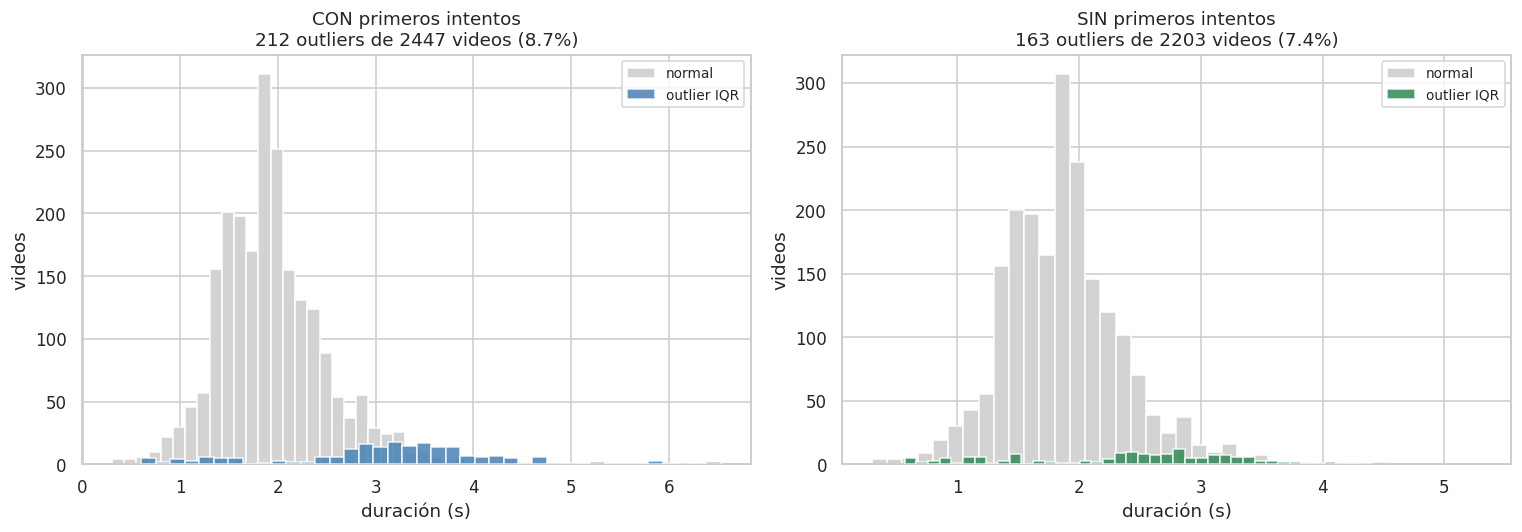

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, titulo, color in zip(
    axes,
    [df_out, df_sin_primeros],
    ['CON primeros intentos', 'SIN primeros intentos'],
    ['steelblue', 'seagreen'],
):
    out = df[df['outlier_iqr']]
    normal = df[~df['outlier_iqr']]

    normal['duration_s'].hist(bins=40, ax=ax, color='lightgrey',
                               edgecolor='white', label='normal', zorder=2)
    out['duration_s'].hist(bins=40, ax=ax, color=color,
                            edgecolor='white', alpha=0.85, label='outlier IQR', zorder=3)

    ax.set_title(f'{titulo}\n{len(out)} outliers de {len(df)} videos ({len(out)/len(df)*100:.1f}%)')
    ax.set_xlabel('duración (s)')
    ax.set_ylabel('videos')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()